In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import LocalOutlierFactor
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from enum import Enum
import os
import shutil
from sklearn.ensemble import GradientBoostingClassifier
import time
from datetime import datetime
import torch
from typing import List, Dict, Any

In [11]:
from temain import TemainProcess
import importlib
import v2_utils
import generators
import autoencoders
importlib.reload(v2_utils)
# importlib.reload(generators)
# importlib.reload(autoencoders)
from v2_utils import CSVDataLoader, ExperimentRunner, plot_with_anomalies, AdvancedDetectionEvaluator, BaseAnomalyDetector, ExperimentRunner
from autoencoders import RecurrentAutoencoder
from generators import ParallelDataGenerator, SingleProcessGenerator, N_DV

In [12]:
def recreate_dir(path):
    if os.path.exists(path):
        shutil.rmtree(path)
    os.makedirs(path)

def run_experiments_by_anomaly(
        anomaly_numbers: List[int],
        data_dir_template: str = "./gen_data/gen_data_{}",
        model_params_list=None,
        file_fraction=0.01,
        anomaly_ratio=0.11,
        max_samples=None,
        result_title="",
        results_path="./results/my",
        window=30,
        autoencoder=None,
    ):
    timestamp = datetime.now().strftime("%Y-%m-%d_%H:%M:%S")
    results_path = f"{results_path}/{timestamp}_{result_title if result_title else ""}"
    recreate_dir(results_path)
    # timestamp = "-"
    normal_dir = data_dir_template.format(0)
    all_best_models = []
    all_best_per_detector = []
    
    for i in anomaly_numbers:
        print(f"\n{'='*50}")
        print(f"Запуск экспериментов для аномалии {i}")
        print(f"{'='*50}")
        start_time = time.time()
        
        data_dir = data_dir_template.format(i)
        
        
        data_gen = CSVDataLoader(data_dir, 
                                 file_fraction=file_fraction,
                                 normal_dir=normal_dir, 
                                 max_samples=max_samples,
                                 anomaly_ratio=anomaly_ratio,
                                 shuffle=True,
                                 normalize=True)
        
        runner = ExperimentRunner(data_gen, evaluator=AdvancedDetectionEvaluator)
        
        runner.register_detector(
            'IsolationForest', 
            IsolationForest,
            {'random_state': 42, 'contamination': 0.1}
        )

        runner.register_detector(
            'LocalOutlierFactor', 
            LocalOutlierFactor,
            {'contamination': 0.1, "novelty": True}
        )

        runner.register_detector(
            'OneClassSVM', 
            OneClassSVM,
            {'kernel': 'linear', 'nu': 0.1} # {'kernel': 'rbf', 'gamma': 'auto', 'nu': 0.1}
        )
        # runner.register_detector(
        #     'GradientBoosting', 
        #     GradientBoostingClassifier,
        #     {'random_state': 42}
        # )
        
        results = runner.run_comprehensive_experiments(
            model_params_list=model_params_list,
            test_delays=None,
            autoencoder=autoencoder,
            window=window,
        )
        
        # filename = f"{results_path}/experiments_results_{i}.csv"
        # results.to_csv(filename, index=False)
        # print(f"Результаты сохранены в {filename}")
        
        best_pr = runner.get_best_models('pr_auc', top_k=1)
        best_pr['anomaly_number'] = i
        best_pr['best_by_metric'] = 'pr_auc'
        all_best_models.append(best_pr)
        scores_filename = f"{results_path}/scores_ANOM{i}.npy"
        np.save(scores_filename, np.stack([best_pr["test_scores"], best_pr["test_target"]]))
        print(f"Скоры и метки для test сохранены в {scores_filename}")
        
        best_roc = runner.get_best_models('roc_auc', top_k=1)
        best_roc['anomaly_number'] = i
        best_roc['best_by_metric'] = 'roc_auc'
        all_best_models.append(best_roc)
        # f1 ?
        
        best_per_detector = runner.get_best_per_detector('pr_auc')
        if not best_per_detector.empty:
            best_per_detector['anomaly_number'] = i
            all_best_per_detector.append(best_per_detector)
        if best_pr.iloc[0]["survival_km"]:
            best_pr.iloc[0]["survival_km"].plot_survival_function()
            plt.title('Функции выживаемости времени обнаружения аномалий')
            plt.ylabel('Вероятность необнаружения аномалии')
            plt.xlabel('Время (шаги)')
            # plt.ylim(0, 1)
            plt.grid(True)
            plt.show()
        
        print(f"Аномалия {i}:")
        print(f"  - Лучший PR AUC: {best_pr['pr_auc'].iloc[0]:.4f} ({best_pr['detector'].iloc[0]})")
        print(f"  - Лучший ROC AUC: {best_roc['roc_auc'].iloc[0]:.4f} ({best_roc['detector'].iloc[0]})")
        # print(f"  - Лучший F1: {best_f1['f1_score'].iloc[0]:.4f} ({best_f1['detector'].iloc[0]})")
        cur = time.time()
        print(f"\n-------------------\nВремя выполнения: {cur - start_time:.4f} секунд\n")
    
    if all_best_models and all_best_per_detector:
        summary_df = pd.concat(all_best_models, ignore_index=True)
        numeric_cols = summary_df.select_dtypes(include=['number', 'bool', 'int64', 'float64', 'string']).columns.tolist()
        numeric_cols += [col for col in summary_df.columns if summary_df[col].dtype == 'object' and all(isinstance(x, str) for x in summary_df[col].dropna().head(10))]
        summary_df = summary_df[numeric_cols]
        summary_filename = f"{results_path}/best_models_summary.csv"
        summary_df.to_csv(summary_filename, index=False)
        print(f"\nСводная таблица сохранена в {summary_filename}")
        
        per_detector_df = pd.concat(all_best_per_detector, ignore_index=True)
        pivot_df = per_detector_df.pivot_table(
            index='anomaly_number', 
            columns='detector', 
            values='pr_auc',
            aggfunc='first'
        )
        pivot_filename = f"{results_path}/pr_auc_pivot.csv"
        pivot_df.to_csv(pivot_filename)
        print(f"Сводная таблица PR AUC по детекторам сохранена в {pivot_filename}")
        return summary_df, pivot_df
    return None, None




Запуск экспериментов для аномалии 1
   Итого: X.shape=(97580, 15, 53), y.shape=(97580,)
   Доля аномалий: 0.0922
Применяем автоэнкодер к данным. Исходная форма: (97580, 15, 53)
После автоэнкодера: (97580, 32)
X_train.shape=(67864, 32), y_train.shape=(67864,), X_test.shape=(29716, 32), y_test.shape=(29716,), y_train.mean()=np.float64(0.09725333018979135), y_test.mean()=np.float64(0.08076457127473415)
Скоры и метки для test сохранены в results/cleared/scores_2026-05-12_19:37:18_ANOM1_new_reduced_data_unsupervised_with_autoencoder.npy


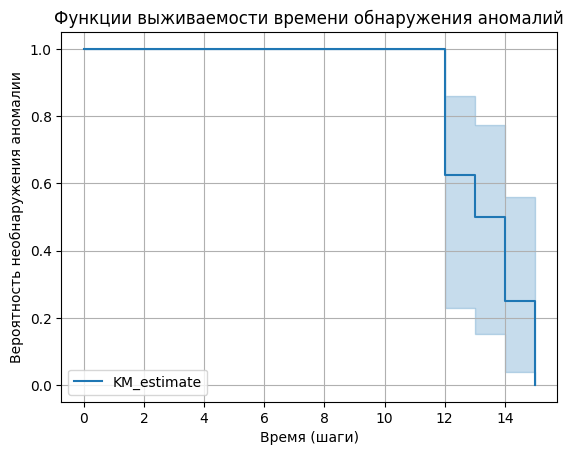

Аномалия 1:
  - Лучший PR AUC: 0.9689 (IsolationForest)
  - Лучший ROC AUC: 0.9825 (IsolationForest)

-------------------
Время выполнения: 294.0527 секунд


Запуск экспериментов для аномалии 2
   Итого: X.shape=(97580, 15, 53), y.shape=(97580,)
   Доля аномалий: 0.0922
Применяем автоэнкодер к данным. Исходная форма: (97580, 15, 53)
После автоэнкодера: (97580, 32)
X_train.shape=(67864, 32), y_train.shape=(67864,), X_test.shape=(29716, 32), y_test.shape=(29716,), y_train.mean()=np.float64(0.09725333018979135), y_test.mean()=np.float64(0.08076457127473415)
Скоры и метки для test сохранены в results/cleared/scores_2026-05-12_19:37:18_ANOM2_new_reduced_data_unsupervised_with_autoencoder.npy


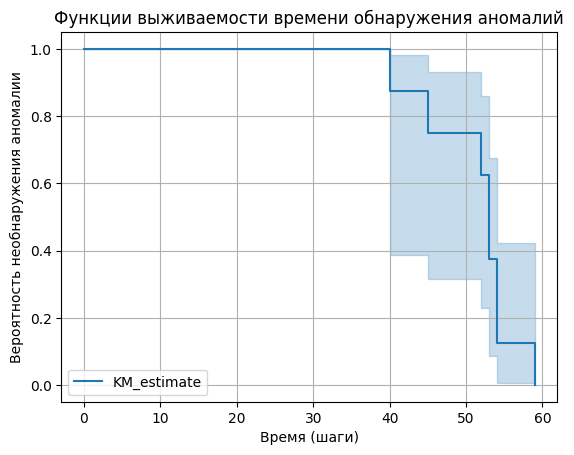

Аномалия 2:
  - Лучший PR AUC: 0.8486 (IsolationForest)
  - Лучший ROC AUC: 0.9324 (IsolationForest)

-------------------
Время выполнения: 220.8313 секунд


Запуск экспериментов для аномалии 3
   Итого: X.shape=(97580, 15, 53), y.shape=(97580,)
   Доля аномалий: 0.0922
Применяем автоэнкодер к данным. Исходная форма: (97580, 15, 53)
После автоэнкодера: (97580, 32)
X_train.shape=(67864, 32), y_train.shape=(67864,), X_test.shape=(29716, 32), y_test.shape=(29716,), y_train.mean()=np.float64(0.09725333018979135), y_test.mean()=np.float64(0.08076457127473415)
Скоры и метки для test сохранены в results/cleared/scores_2026-05-12_19:37:18_ANOM3_new_reduced_data_unsupervised_with_autoencoder.npy


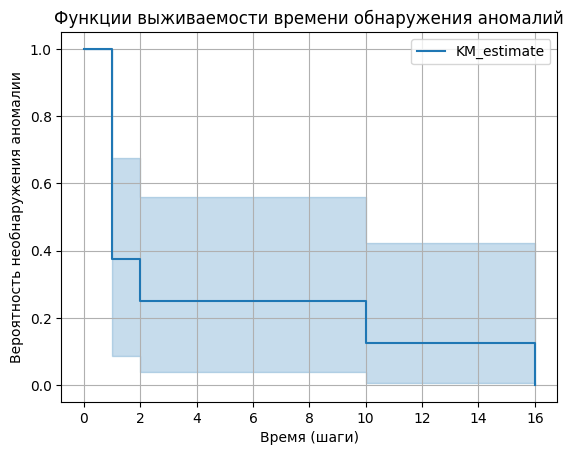

Аномалия 3:
  - Лучший PR AUC: 0.0847 (LocalOutlierFactor)
  - Лучший ROC AUC: 0.5281 (LocalOutlierFactor)

-------------------
Время выполнения: 246.8212 секунд


Запуск экспериментов для аномалии 4
   Итого: X.shape=(97580, 15, 53), y.shape=(97580,)
   Доля аномалий: 0.0922
Применяем автоэнкодер к данным. Исходная форма: (97580, 15, 53)
После автоэнкодера: (97580, 32)
X_train.shape=(67864, 32), y_train.shape=(67864,), X_test.shape=(29716, 32), y_test.shape=(29716,), y_train.mean()=np.float64(0.09725333018979135), y_test.mean()=np.float64(0.08076457127473415)
Скоры и метки для test сохранены в results/cleared/scores_2026-05-12_19:37:18_ANOM4_new_reduced_data_unsupervised_with_autoencoder.npy


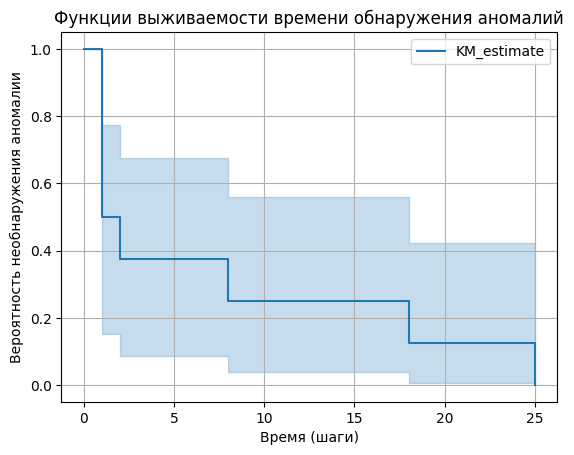

Аномалия 4:
  - Лучший PR AUC: 0.1199 (LocalOutlierFactor)
  - Лучший ROC AUC: 0.6283 (LocalOutlierFactor)

-------------------
Время выполнения: 255.1742 секунд


Запуск экспериментов для аномалии 5
   Итого: X.shape=(97580, 15, 53), y.shape=(97580,)
   Доля аномалий: 0.0922
Применяем автоэнкодер к данным. Исходная форма: (97580, 15, 53)
После автоэнкодера: (97580, 32)
X_train.shape=(67864, 32), y_train.shape=(67864,), X_test.shape=(29716, 32), y_test.shape=(29716,), y_train.mean()=np.float64(0.09725333018979135), y_test.mean()=np.float64(0.08076457127473415)
Скоры и метки для test сохранены в results/cleared/scores_2026-05-12_19:37:18_ANOM5_new_reduced_data_unsupervised_with_autoencoder.npy


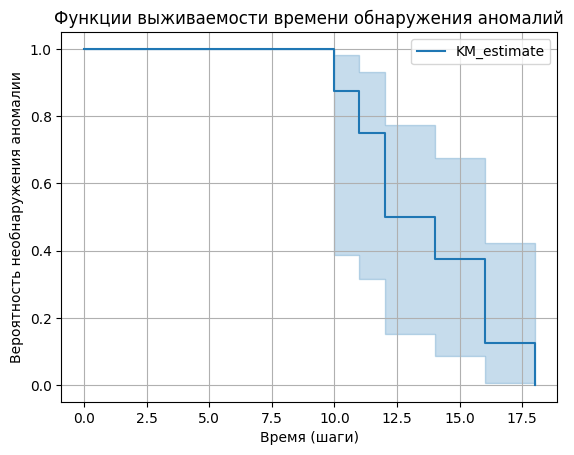

Аномалия 5:
  - Лучший PR AUC: 0.7278 (IsolationForest)
  - Лучший ROC AUC: 0.8718 (IsolationForest)

-------------------
Время выполнения: 240.2451 секунд


Запуск экспериментов для аномалии 6
   Итого: X.shape=(97580, 15, 53), y.shape=(97580,)
   Доля аномалий: 0.0922
Применяем автоэнкодер к данным. Исходная форма: (97580, 15, 53)
После автоэнкодера: (97580, 32)
X_train.shape=(67864, 32), y_train.shape=(67864,), X_test.shape=(29716, 32), y_test.shape=(29716,), y_train.mean()=np.float64(0.09725333018979135), y_test.mean()=np.float64(0.08076457127473415)
Скоры и метки для test сохранены в results/cleared/scores_2026-05-12_19:37:18_ANOM6_new_reduced_data_unsupervised_with_autoencoder.npy


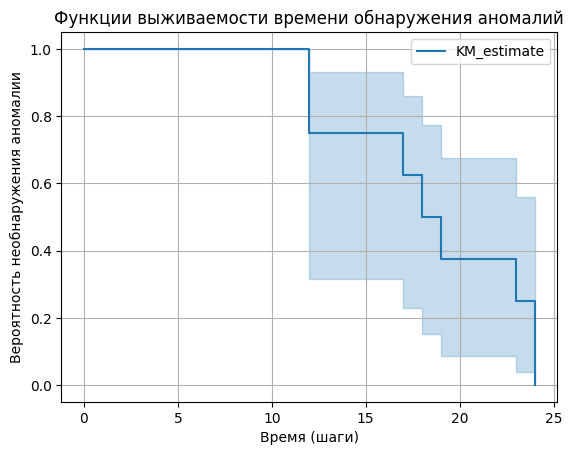

Аномалия 6:
  - Лучший PR AUC: 0.9684 (IsolationForest)
  - Лучший ROC AUC: 0.9821 (IsolationForest)

-------------------
Время выполнения: 264.9527 секунд


Запуск экспериментов для аномалии 7
   Итого: X.shape=(97580, 15, 53), y.shape=(97580,)
   Доля аномалий: 0.0922
Применяем автоэнкодер к данным. Исходная форма: (97580, 15, 53)
После автоэнкодера: (97580, 32)
X_train.shape=(67864, 32), y_train.shape=(67864,), X_test.shape=(29716, 32), y_test.shape=(29716,), y_train.mean()=np.float64(0.09725333018979135), y_test.mean()=np.float64(0.08076457127473415)
Скоры и метки для test сохранены в results/cleared/scores_2026-05-12_19:37:18_ANOM7_new_reduced_data_unsupervised_with_autoencoder.npy


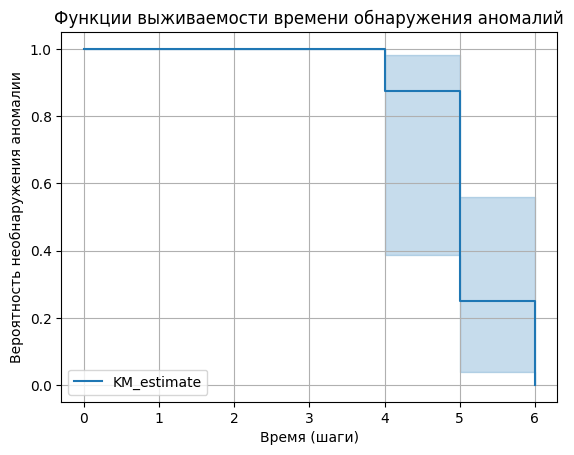

Аномалия 7:
  - Лучший PR AUC: 0.9721 (IsolationForest)
  - Лучший ROC AUC: 0.9913 (IsolationForest)

-------------------
Время выполнения: 225.0865 секунд


Запуск экспериментов для аномалии 8
   Итого: X.shape=(97580, 15, 53), y.shape=(97580,)
   Доля аномалий: 0.0922
Применяем автоэнкодер к данным. Исходная форма: (97580, 15, 53)
После автоэнкодера: (97580, 32)
X_train.shape=(67864, 32), y_train.shape=(67864,), X_test.shape=(29716, 32), y_test.shape=(29716,), y_train.mean()=np.float64(0.09725333018979135), y_test.mean()=np.float64(0.08076457127473415)
Скоры и метки для test сохранены в results/cleared/scores_2026-05-12_19:37:18_ANOM8_new_reduced_data_unsupervised_with_autoencoder.npy


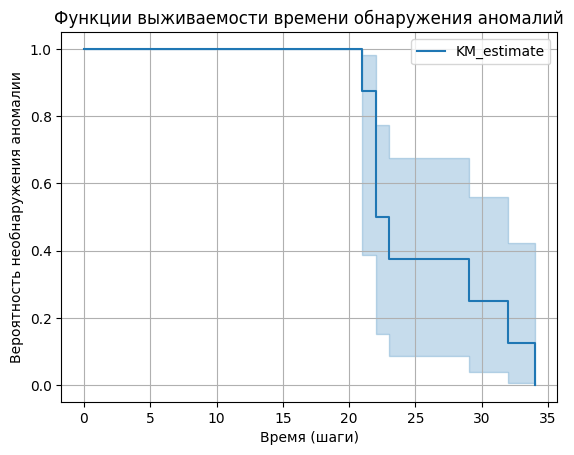

Аномалия 8:
  - Лучший PR AUC: 0.9359 (IsolationForest)
  - Лучший ROC AUC: 0.9628 (IsolationForest)

-------------------
Время выполнения: 242.1295 секунд


Запуск экспериментов для аномалии 9
   Итого: X.shape=(97580, 15, 53), y.shape=(97580,)
   Доля аномалий: 0.0922
Применяем автоэнкодер к данным. Исходная форма: (97580, 15, 53)
После автоэнкодера: (97580, 32)
X_train.shape=(67864, 32), y_train.shape=(67864,), X_test.shape=(29716, 32), y_test.shape=(29716,), y_train.mean()=np.float64(0.09725333018979135), y_test.mean()=np.float64(0.08076457127473415)
Скоры и метки для test сохранены в results/cleared/scores_2026-05-12_19:37:18_ANOM9_new_reduced_data_unsupervised_with_autoencoder.npy


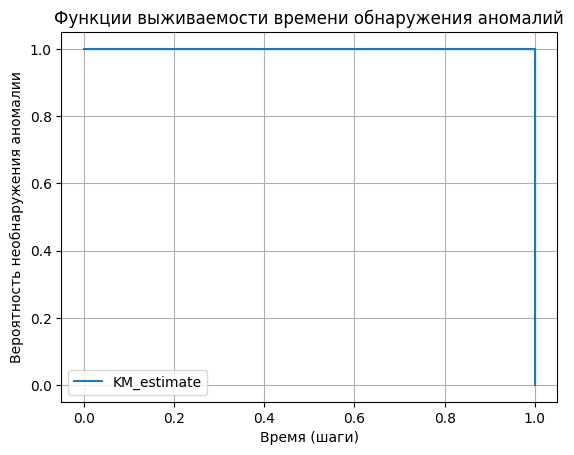

Аномалия 9:
  - Лучший PR AUC: 0.0838 (LocalOutlierFactor)
  - Лучший ROC AUC: 0.5236 (LocalOutlierFactor)

-------------------
Время выполнения: 245.3261 секунд


Запуск экспериментов для аномалии 10
   Итого: X.shape=(97580, 15, 53), y.shape=(97580,)
   Доля аномалий: 0.0922
Применяем автоэнкодер к данным. Исходная форма: (97580, 15, 53)
После автоэнкодера: (97580, 32)
X_train.shape=(67864, 32), y_train.shape=(67864,), X_test.shape=(29716, 32), y_test.shape=(29716,), y_train.mean()=np.float64(0.09725333018979135), y_test.mean()=np.float64(0.08076457127473415)
Скоры и метки для test сохранены в results/cleared/scores_2026-05-12_19:37:18_ANOM10_new_reduced_data_unsupervised_with_autoencoder.npy


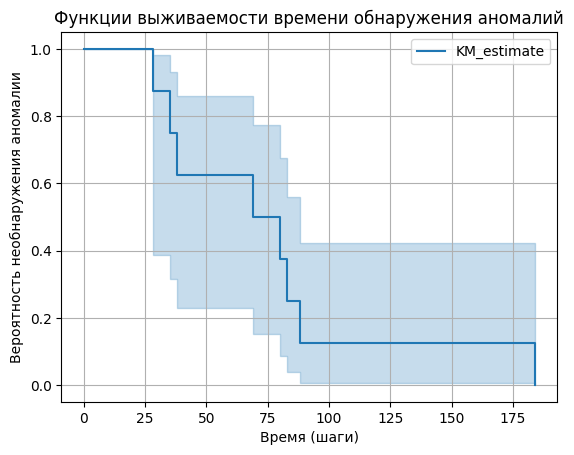

Аномалия 10:
  - Лучший PR AUC: 0.4578 (IsolationForest)
  - Лучший ROC AUC: 0.7768 (IsolationForest)

-------------------
Время выполнения: 243.3844 секунд


Запуск экспериментов для аномалии 11
   Итого: X.shape=(97580, 15, 53), y.shape=(97580,)
   Доля аномалий: 0.0922
Применяем автоэнкодер к данным. Исходная форма: (97580, 15, 53)
После автоэнкодера: (97580, 32)
X_train.shape=(67864, 32), y_train.shape=(67864,), X_test.shape=(29716, 32), y_test.shape=(29716,), y_train.mean()=np.float64(0.09725333018979135), y_test.mean()=np.float64(0.08076457127473415)
Скоры и метки для test сохранены в results/cleared/scores_2026-05-12_19:37:18_ANOM11_new_reduced_data_unsupervised_with_autoencoder.npy


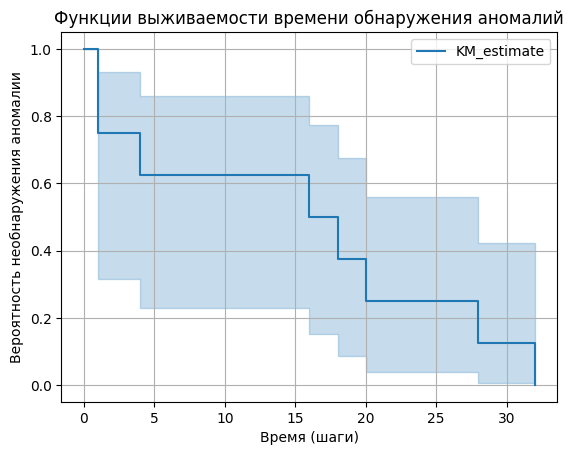

Аномалия 11:
  - Лучший PR AUC: 0.1111 (LocalOutlierFactor)
  - Лучший ROC AUC: 0.5898 (LocalOutlierFactor)

-------------------
Время выполнения: 240.9668 секунд


Запуск экспериментов для аномалии 12
   Итого: X.shape=(97580, 15, 53), y.shape=(97580,)
   Доля аномалий: 0.0922
Применяем автоэнкодер к данным. Исходная форма: (97580, 15, 53)
После автоэнкодера: (97580, 32)
X_train.shape=(67864, 32), y_train.shape=(67864,), X_test.shape=(29716, 32), y_test.shape=(29716,), y_train.mean()=np.float64(0.09725333018979135), y_test.mean()=np.float64(0.08076457127473415)
Скоры и метки для test сохранены в results/cleared/scores_2026-05-12_19:37:18_ANOM12_new_reduced_data_unsupervised_with_autoencoder.npy


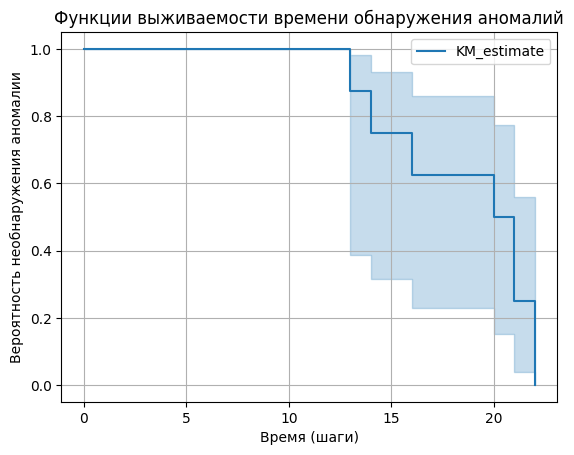

Аномалия 12:
  - Лучший PR AUC: 0.9471 (IsolationForest)
  - Лучший ROC AUC: 0.9694 (IsolationForest)

-------------------
Время выполнения: 233.6846 секунд


Запуск экспериментов для аномалии 13
   Итого: X.shape=(97580, 15, 53), y.shape=(97580,)
   Доля аномалий: 0.0922
Применяем автоэнкодер к данным. Исходная форма: (97580, 15, 53)
После автоэнкодера: (97580, 32)
X_train.shape=(67864, 32), y_train.shape=(67864,), X_test.shape=(29716, 32), y_test.shape=(29716,), y_train.mean()=np.float64(0.09725333018979135), y_test.mean()=np.float64(0.08076457127473415)
Скоры и метки для test сохранены в results/cleared/scores_2026-05-12_19:37:18_ANOM13_new_reduced_data_unsupervised_with_autoencoder.npy


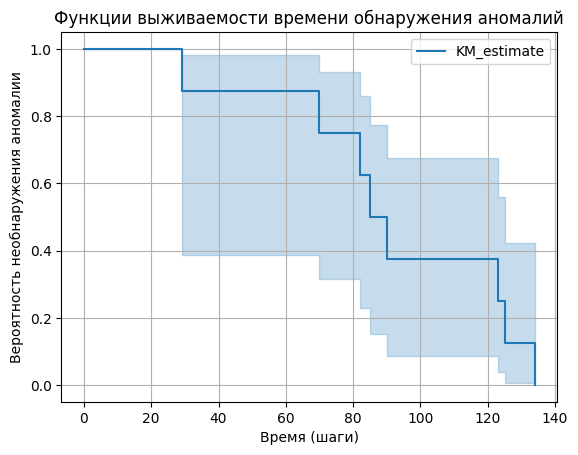

Аномалия 13:
  - Лучший PR AUC: 0.7914 (IsolationForest)
  - Лучший ROC AUC: 0.8900 (IsolationForest)

-------------------
Время выполнения: 272.4602 секунд


Запуск экспериментов для аномалии 14
   Итого: X.shape=(97580, 15, 53), y.shape=(97580,)
   Доля аномалий: 0.0922
Применяем автоэнкодер к данным. Исходная форма: (97580, 15, 53)
После автоэнкодера: (97580, 32)
X_train.shape=(67864, 32), y_train.shape=(67864,), X_test.shape=(29716, 32), y_test.shape=(29716,), y_train.mean()=np.float64(0.09725333018979135), y_test.mean()=np.float64(0.08076457127473415)
Скоры и метки для test сохранены в results/cleared/scores_2026-05-12_19:37:18_ANOM14_new_reduced_data_unsupervised_with_autoencoder.npy


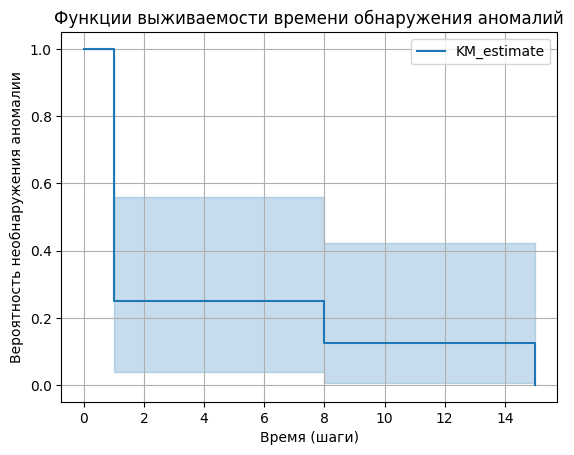

Аномалия 14:
  - Лучший PR AUC: 0.0852 (LocalOutlierFactor)
  - Лучший ROC AUC: 0.5303 (LocalOutlierFactor)

-------------------
Время выполнения: 241.9688 секунд


Запуск экспериментов для аномалии 15
   Итого: X.shape=(97580, 15, 53), y.shape=(97580,)
   Доля аномалий: 0.0922
Применяем автоэнкодер к данным. Исходная форма: (97580, 15, 53)
После автоэнкодера: (97580, 32)
X_train.shape=(67864, 32), y_train.shape=(67864,), X_test.shape=(29716, 32), y_test.shape=(29716,), y_train.mean()=np.float64(0.09725333018979135), y_test.mean()=np.float64(0.08076457127473415)
Скоры и метки для test сохранены в results/cleared/scores_2026-05-12_19:37:18_ANOM15_new_reduced_data_unsupervised_with_autoencoder.npy


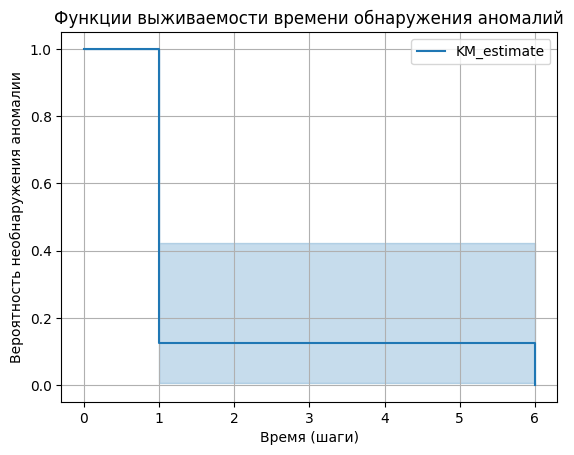

Аномалия 15:
  - Лучший PR AUC: 0.0884 (LocalOutlierFactor)
  - Лучший ROC AUC: 0.5479 (LocalOutlierFactor)

-------------------
Время выполнения: 246.9285 секунд


Запуск экспериментов для аномалии 16
   Итого: X.shape=(97580, 15, 53), y.shape=(97580,)
   Доля аномалий: 0.0922
Применяем автоэнкодер к данным. Исходная форма: (97580, 15, 53)
После автоэнкодера: (97580, 32)
X_train.shape=(67864, 32), y_train.shape=(67864,), X_test.shape=(29716, 32), y_test.shape=(29716,), y_train.mean()=np.float64(0.09725333018979135), y_test.mean()=np.float64(0.08076457127473415)
Скоры и метки для test сохранены в results/cleared/scores_2026-05-12_19:37:18_ANOM16_new_reduced_data_unsupervised_with_autoencoder.npy


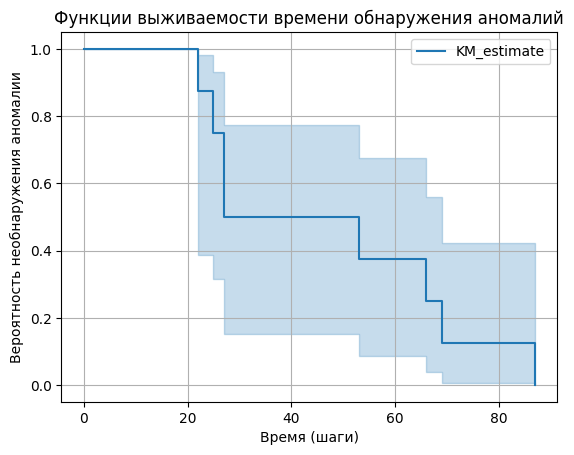

Аномалия 16:
  - Лучший PR AUC: 0.1619 (IsolationForest)
  - Лучший ROC AUC: 0.6529 (IsolationForest)

-------------------
Время выполнения: 242.2415 секунд


Запуск экспериментов для аномалии 17
   Итого: X.shape=(97580, 15, 53), y.shape=(97580,)
   Доля аномалий: 0.0922
Применяем автоэнкодер к данным. Исходная форма: (97580, 15, 53)
После автоэнкодера: (97580, 32)
X_train.shape=(67864, 32), y_train.shape=(67864,), X_test.shape=(29716, 32), y_test.shape=(29716,), y_train.mean()=np.float64(0.09725333018979135), y_test.mean()=np.float64(0.08076457127473415)
Скоры и метки для test сохранены в results/cleared/scores_2026-05-12_19:37:18_ANOM17_new_reduced_data_unsupervised_with_autoencoder.npy


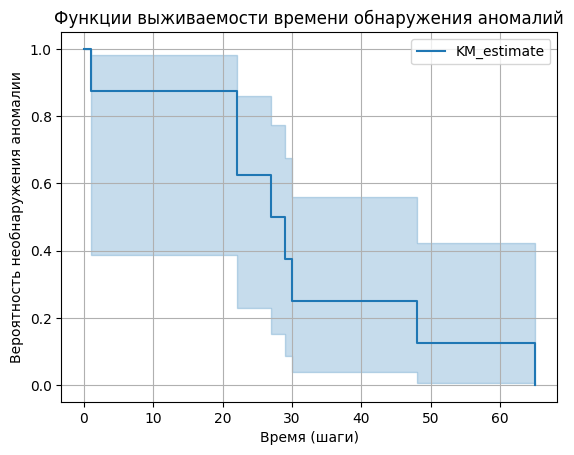

Аномалия 17:
  - Лучший PR AUC: 0.2978 (LocalOutlierFactor)
  - Лучший ROC AUC: 0.7399 (LocalOutlierFactor)

-------------------
Время выполнения: 252.4085 секунд


Запуск экспериментов для аномалии 18
   Итого: X.shape=(97580, 15, 53), y.shape=(97580,)
   Доля аномалий: 0.0922
Применяем автоэнкодер к данным. Исходная форма: (97580, 15, 53)
После автоэнкодера: (97580, 32)
X_train.shape=(67864, 32), y_train.shape=(67864,), X_test.shape=(29716, 32), y_test.shape=(29716,), y_train.mean()=np.float64(0.09725333018979135), y_test.mean()=np.float64(0.08076457127473415)
Скоры и метки для test сохранены в results/cleared/scores_2026-05-12_19:37:18_ANOM18_new_reduced_data_unsupervised_with_autoencoder.npy


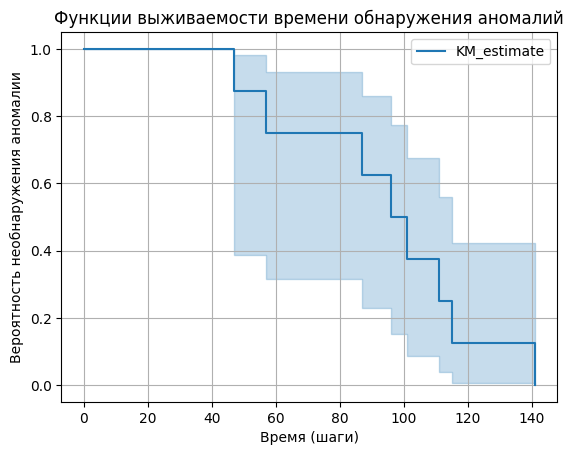

Аномалия 18:
  - Лучший PR AUC: 0.7662 (IsolationForest)
  - Лучший ROC AUC: 0.8627 (IsolationForest)

-------------------
Время выполнения: 248.7867 секунд


Запуск экспериментов для аномалии 19
   Итого: X.shape=(97580, 15, 53), y.shape=(97580,)
   Доля аномалий: 0.0922
Применяем автоэнкодер к данным. Исходная форма: (97580, 15, 53)
После автоэнкодера: (97580, 32)
X_train.shape=(67864, 32), y_train.shape=(67864,), X_test.shape=(29716, 32), y_test.shape=(29716,), y_train.mean()=np.float64(0.09725333018979135), y_test.mean()=np.float64(0.08076457127473415)
Скоры и метки для test сохранены в results/cleared/scores_2026-05-12_19:37:18_ANOM19_new_reduced_data_unsupervised_with_autoencoder.npy


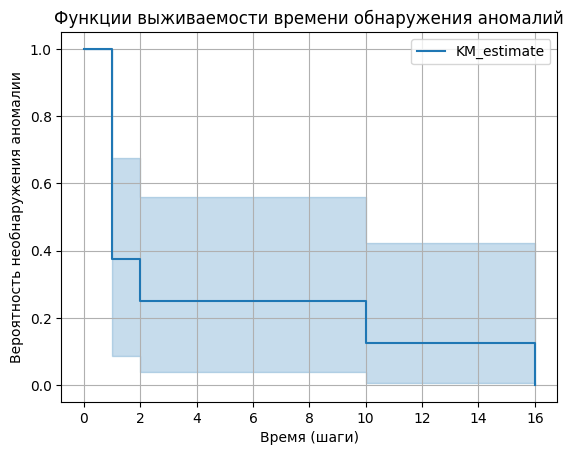

Аномалия 19:
  - Лучший PR AUC: 0.0855 (LocalOutlierFactor)
  - Лучший ROC AUC: 0.5355 (LocalOutlierFactor)

-------------------
Время выполнения: 249.9936 секунд


Сводная таблица сохранена в results/cleared/best_models_summary_2026-05-12_19:37:18_new_reduced_data_unsupervised_with_autoencoder.csv
Сводная таблица PR AUC по детекторам сохранена в results/cleared/pr_auc_pivot_2026-05-12_19:37:18_new_reduced_data_unsupervised_with_autoencoder.csv


In [4]:
model_params_list = {
    'IsolationForest': [
        {'n_estimators': 200, 'contamination': 0.1, "random_state": 42},
        {'n_estimators': 100, 'max_samples': 'auto', 'contamination': 0.1, 'random_state': 42},
        {'n_estimators': 200, 'max_samples': 0.8, 'contamination': 0.05, 'random_state': 42},
        {'n_estimators': 50, 'max_samples': 1.0, 'contamination': 0.1, 'random_state': 42},
        {'n_estimators': 100, 'max_samples': 0.5, 'contamination': 'auto', 'random_state': 42}
    ],
    'LocalOutlierFactor': [
        {'n_neighbors': 50, 'contamination': 0.1, 'novelty': True},
        {'n_neighbors': 20, 'contamination': 0.1, 'novelty': True},
        {'n_neighbors': 10, 'contamination': 0.05, 'novelty': True},
        {'n_neighbors': 10, 'contamination': 0.1, 'novelty': True},
        {'n_neighbors': 50, 'contamination': 0.15, 'novelty': True},
        {'n_neighbors': 20, 'contamination': 'auto', 'novelty': True}
    ],
    'OneClassSVM': [
        # {'kernel': 'rbf', 'nu': 0.1},
        # {'kernel': 'rbf', 'nu': 0.15},
        {'kernel': 'linear', 'nu': 0.15},
        {'kernel': 'linear', 'nu': 0.2},
        {'kernel': 'linear', 'nu': 0.10},
        # {'kernel': 'poly', 'nu': 0.15},
    ],
    # 'GradientBoosting': [
    #     {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.1, 'random_state': 42},
    #     {'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.05, 'random_state': 42},
    #     {'n_estimators': 100, 'max_depth': 5, 'learning_rate': 0.01, 'random_state': 42},
    # ]
}

autoencoder = RecurrentAutoencoder(
            input_dim=53,
            window_size=30,
            hidden_dim=64,
            latent_dim=32,
            num_layers=1
        )
model_saved_path = f"./models/new_autoencoder_w15.pth"
# model_saved_path = f"./models/new_autoencoder_layer2_w15.pth"

autoencoder.load_state_dict(torch.load(model_saved_path))
autoencoder.eval()

anomaly_numbers = list(range(1, 20))
# anomaly_numbers = [1]

summary, summary_detectors = run_experiments_by_anomaly(anomaly_numbers,
                                     data_dir_template="./gen_data_reduced/gen_data_{}",
                                     model_params_list=model_params_list,
                                     max_samples=100000,
                                     file_fraction=0.05,
                                     anomaly_ratio=0.08,
                                     window=15,
                                     result_title="new_reduced_data_unsupervised_with_autoencoder",
                                     results_path="results/cleared",
                                     autoencoder=autoencoder,
                                     )

In [5]:
summary

,roc_auc,pr_auc,optimal_thr,eer,precision,recall,f1_score,accuracy,fdr,far,...,random_state,size,anomaly_ratio,n_neighbors,nu,anomaly_number,detector,freq,kernel,best_by_metric
0,0.982481,0.968926,0.536600,0.032107,0.962916,0.941250,0.951960,0.992327,0.941250,0.003185,...,42.0,97580,0.092232,NaN,NaN,1,IsolationForest,3min,NaN,pr_auc
1,0.982481,0.968926,0.536600,0.032107,0.962916,0.941250,0.951960,0.992327,0.941250,0.003185,...,42.0,97580,0.092232,NaN,NaN,1,IsolationForest,3min,NaN,roc_auc
2,0.932386,0.848589,0.579093,0.126403,0.864816,0.791667,0.826626,0.973179,0.791667,0.010873,...,42.0,97580,0.092232,NaN,NaN,2,IsolationForest,3min,NaN,pr_auc
3,0.932386,0.848589,0.579093,0.126403,0.864816,0.791667,0.826626,0.973179,0.791667,0.010873,...,42.0,97580,0.092232,NaN,NaN,2,IsolationForest,3min,NaN,roc_auc
4,0.528078,0.084694,0.157505,0.477456,0.087096,0.722500,0.155453,0.365964,0.722500,0.665361,...,NaN,97580,0.092232,50.0,NaN,3,LocalOutlierFactor,3min,NaN,pr_auc
5,0.528078,0.084694,0.157505,0.477456,0.087096,0.722500,0.155453,0.365964,0.722500,0.665361,...,NaN,97580,0.092232,50.0,NaN,3,LocalOutlierFactor,3min,NaN,roc_auc
6,0.628313,0.119943,0.238365,0.410418,0.113892,0.578333,0.190306,0.602537,0.578333,0.395336,...,NaN,97580,0.092232,50.0,NaN,4,LocalOutlierFactor,3min,NaN,pr_auc
7,0.628313,0.119943,0.238365,0.410418,0.113892,0.578333,0.190306,0.602537,0.578333,0.395336,...,NaN,97580,0.092232,50.0,NaN,4,LocalOutlierFactor,3min,NaN,roc_auc
8,0.869931,0.727778,0.149490,0.218015,0.958913,0.602917,0.740343,0.965843,0.602917,0.002270,...,42.0,97580,0.092232,NaN,NaN,5,IsolationForest,3min,NaN,pr_auc
9,0.871784,0.727072,0.256607,0.219482,0.948905,0.595833,0.732019,0.964766,0.595833,0.002819,...,42.0,97580,0.092232,NaN,NaN,5,IsolationForest,3min,NaN,roc_auc


In [6]:
summary_detectors

detector,IsolationForest,LocalOutlierFactor,OneClassSVM
anomaly_number,,,
1,0.968926,0.087170,0.203225
2,0.848589,0.165853,0.254751
3,0.081235,0.084694,0.072558
4,0.103101,0.119943,0.060519
5,0.727778,0.124131,0.078037
6,0.968377,0.622135,0.846740
7,0.972134,0.116490,0.179252
8,0.935873,0.233045,0.049098
9,0.080286,0.083814,0.080610



Запуск экспериментов для аномалии 1
   Итого: X.shape=(100000, 53), y.shape=(100000,)
   Доля аномалий: 0.0900
X_train.shape=(69416, 53), y_train.shape=(69416,), X_test.shape=(30584, 53), y_test.shape=(30584,), y_train.mean()=np.float64(0.09507894433559987), y_test.mean()=np.float64(0.07847240387130526)
Скоры и метки для test сохранены в results/cleared/2026-05-12_23:33:26_new_reduced_data_unsupervised_no_windows/scores_ANOM1.npy


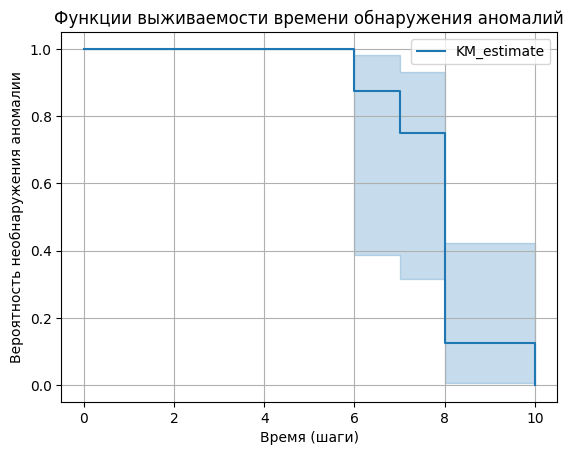

Аномалия 1:
  - Лучший PR AUC: 0.9879 (OneClassSVM)
  - Лучший ROC AUC: 0.9942 (OneClassSVM)

-------------------
Время выполнения: 521.7044 секунд


Запуск экспериментов для аномалии 2
   Итого: X.shape=(100000, 53), y.shape=(100000,)
   Доля аномалий: 0.0900
X_train.shape=(69416, 53), y_train.shape=(69416,), X_test.shape=(30584, 53), y_test.shape=(30584,), y_train.mean()=np.float64(0.09507894433559987), y_test.mean()=np.float64(0.07847240387130526)
Скоры и метки для test сохранены в results/cleared/2026-05-12_23:33:26_new_reduced_data_unsupervised_no_windows/scores_ANOM2.npy


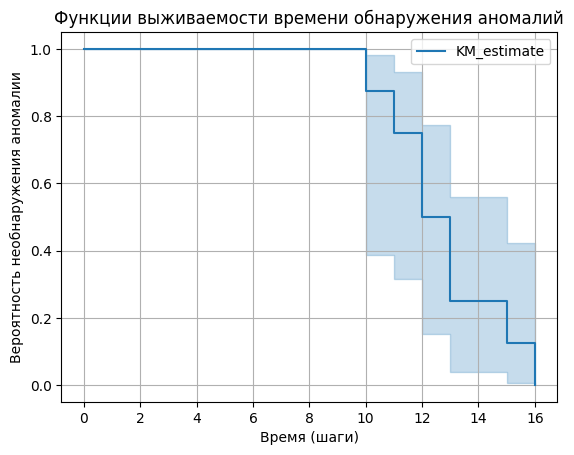

Аномалия 2:
  - Лучший PR AUC: 0.9771 (OneClassSVM)
  - Лучший ROC AUC: 0.9901 (OneClassSVM)

-------------------
Время выполнения: 383.3179 секунд


Запуск экспериментов для аномалии 3
   Итого: X.shape=(100000, 53), y.shape=(100000,)
   Доля аномалий: 0.0900
X_train.shape=(69416, 53), y_train.shape=(69416,), X_test.shape=(30584, 53), y_test.shape=(30584,), y_train.mean()=np.float64(0.09507894433559987), y_test.mean()=np.float64(0.07847240387130526)
Скоры и метки для test сохранены в results/cleared/2026-05-12_23:33:26_new_reduced_data_unsupervised_no_windows/scores_ANOM3.npy


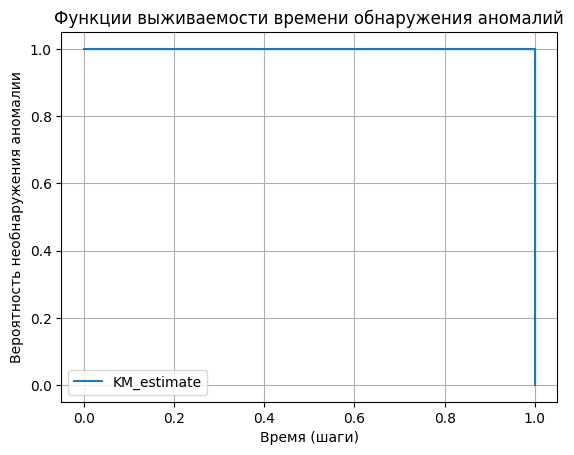

Аномалия 3:
  - Лучший PR AUC: 0.0787 (LocalOutlierFactor)
  - Лучший ROC AUC: 0.5095 (LocalOutlierFactor)

-------------------
Время выполнения: 303.8194 секунд


Запуск экспериментов для аномалии 4
   Итого: X.shape=(100000, 53), y.shape=(100000,)
   Доля аномалий: 0.0900
X_train.shape=(69416, 53), y_train.shape=(69416,), X_test.shape=(30584, 53), y_test.shape=(30584,), y_train.mean()=np.float64(0.09507894433559987), y_test.mean()=np.float64(0.07847240387130526)
Скоры и метки для test сохранены в results/cleared/2026-05-12_23:33:26_new_reduced_data_unsupervised_no_windows/scores_ANOM4.npy


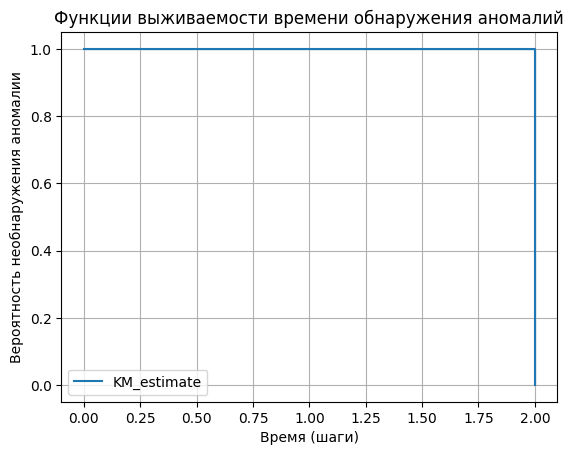

Аномалия 4:
  - Лучший PR AUC: 0.9971 (OneClassSVM)
  - Лучший ROC AUC: 0.9977 (OneClassSVM)

-------------------
Время выполнения: 423.4453 секунд


Запуск экспериментов для аномалии 5
   Итого: X.shape=(100000, 53), y.shape=(100000,)
   Доля аномалий: 0.0900
X_train.shape=(69416, 53), y_train.shape=(69416,), X_test.shape=(30584, 53), y_test.shape=(30584,), y_train.mean()=np.float64(0.09507894433559987), y_test.mean()=np.float64(0.07847240387130526)
Скоры и метки для test сохранены в results/cleared/2026-05-12_23:33:26_new_reduced_data_unsupervised_no_windows/scores_ANOM5.npy


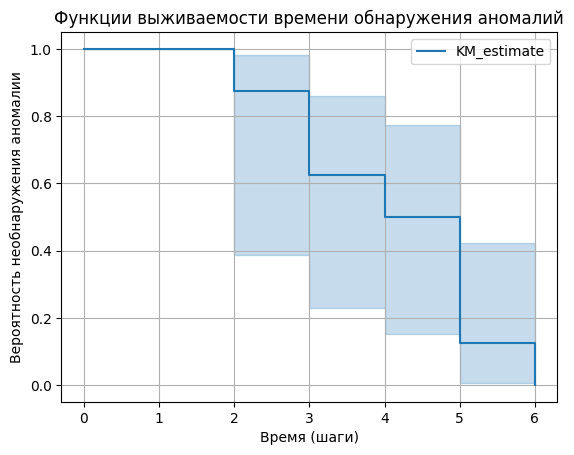

Аномалия 5:
  - Лучший PR AUC: 0.9510 (OneClassSVM)
  - Лучший ROC AUC: 0.9907 (OneClassSVM)

-------------------
Время выполнения: 416.1928 секунд


Запуск экспериментов для аномалии 6
   Итого: X.shape=(100000, 53), y.shape=(100000,)
   Доля аномалий: 0.0900
X_train.shape=(69416, 53), y_train.shape=(69416,), X_test.shape=(30584, 53), y_test.shape=(30584,), y_train.mean()=np.float64(0.09507894433559987), y_test.mean()=np.float64(0.07847240387130526)
Скоры и метки для test сохранены в results/cleared/2026-05-12_23:33:26_new_reduced_data_unsupervised_no_windows/scores_ANOM6.npy


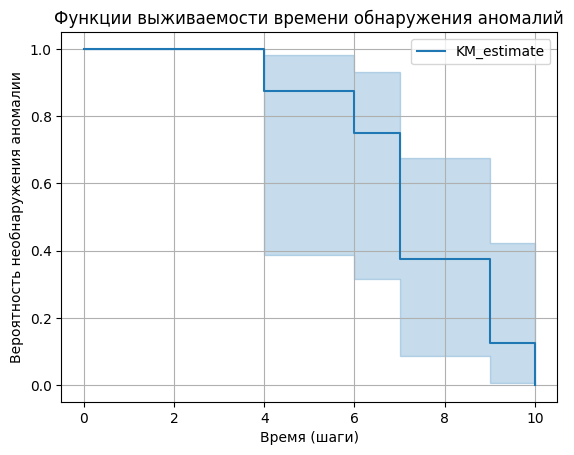

Аномалия 6:
  - Лучший PR AUC: 0.9955 (IsolationForest)
  - Лучший ROC AUC: 0.9994 (IsolationForest)

-------------------
Время выполнения: 310.0507 секунд


Запуск экспериментов для аномалии 7
   Итого: X.shape=(100000, 53), y.shape=(100000,)
   Доля аномалий: 0.0900
X_train.shape=(69416, 53), y_train.shape=(69416,), X_test.shape=(30584, 53), y_test.shape=(30584,), y_train.mean()=np.float64(0.09507894433559987), y_test.mean()=np.float64(0.07847240387130526)
Скоры и метки для test сохранены в results/cleared/2026-05-12_23:33:26_new_reduced_data_unsupervised_no_windows/scores_ANOM7.npy


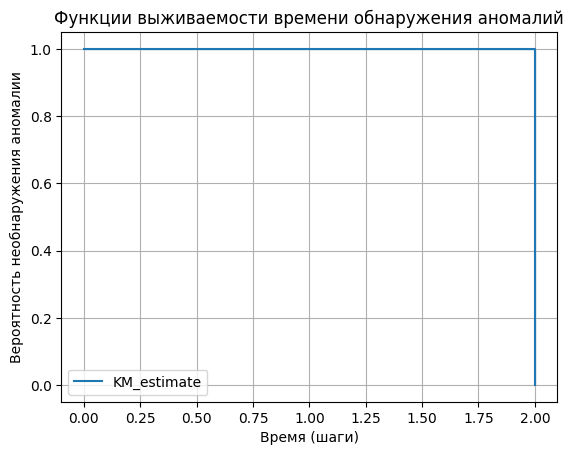

Аномалия 7:
  - Лучший PR AUC: 0.9991 (OneClassSVM)
  - Лучший ROC AUC: 0.9998 (OneClassSVM)

-------------------
Время выполнения: 548.5241 секунд


Запуск экспериментов для аномалии 8
   Итого: X.shape=(100000, 53), y.shape=(100000,)
   Доля аномалий: 0.0900
X_train.shape=(69416, 53), y_train.shape=(69416,), X_test.shape=(30584, 53), y_test.shape=(30584,), y_train.mean()=np.float64(0.09507894433559987), y_test.mean()=np.float64(0.07847240387130526)
Скоры и метки для test сохранены в results/cleared/2026-05-12_23:33:26_new_reduced_data_unsupervised_no_windows/scores_ANOM8.npy


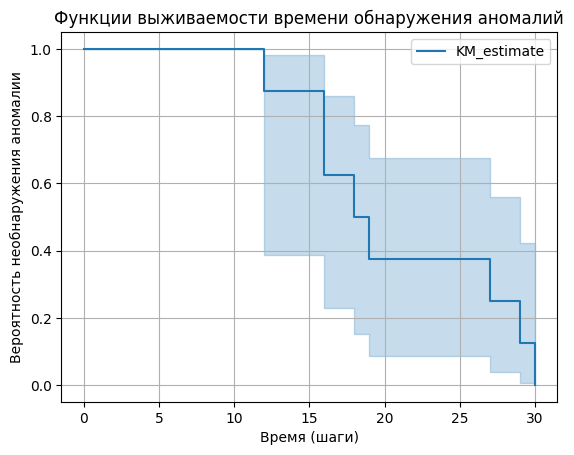

Аномалия 8:
  - Лучший PR AUC: 0.9433 (IsolationForest)
  - Лучший ROC AUC: 0.9703 (IsolationForest)

-------------------
Время выполнения: 347.6618 секунд


Запуск экспериментов для аномалии 9
   Итого: X.shape=(100000, 53), y.shape=(100000,)
   Доля аномалий: 0.0900
X_train.shape=(69416, 53), y_train.shape=(69416,), X_test.shape=(30584, 53), y_test.shape=(30584,), y_train.mean()=np.float64(0.09507894433559987), y_test.mean()=np.float64(0.07847240387130526)
Скоры и метки для test сохранены в results/cleared/2026-05-12_23:33:26_new_reduced_data_unsupervised_no_windows/scores_ANOM9.npy


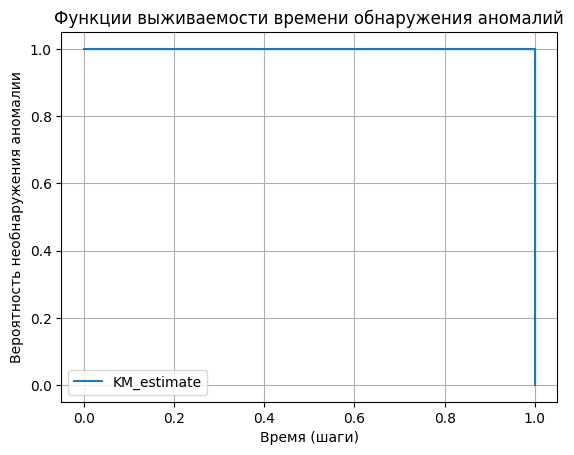

Аномалия 9:
  - Лучший PR AUC: 0.0790 (LocalOutlierFactor)
  - Лучший ROC AUC: 0.5100 (LocalOutlierFactor)

-------------------
Время выполнения: 304.6256 секунд


Запуск экспериментов для аномалии 10
   Итого: X.shape=(100000, 53), y.shape=(100000,)
   Доля аномалий: 0.0900
X_train.shape=(69416, 53), y_train.shape=(69416,), X_test.shape=(30584, 53), y_test.shape=(30584,), y_train.mean()=np.float64(0.09507894433559987), y_test.mean()=np.float64(0.07847240387130526)
Скоры и метки для test сохранены в results/cleared/2026-05-12_23:33:26_new_reduced_data_unsupervised_no_windows/scores_ANOM10.npy


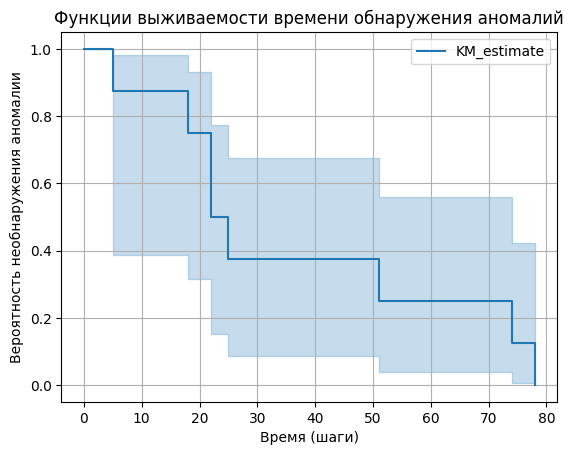

Аномалия 10:
  - Лучший PR AUC: 0.3286 (IsolationForest)
  - Лучший ROC AUC: 0.7478 (LocalOutlierFactor)

-------------------
Время выполнения: 359.4107 секунд


Запуск экспериментов для аномалии 11
   Итого: X.shape=(100000, 53), y.shape=(100000,)
   Доля аномалий: 0.0900
X_train.shape=(69416, 53), y_train.shape=(69416,), X_test.shape=(30584, 53), y_test.shape=(30584,), y_train.mean()=np.float64(0.09507894433559987), y_test.mean()=np.float64(0.07847240387130526)
Скоры и метки для test сохранены в results/cleared/2026-05-12_23:33:26_new_reduced_data_unsupervised_no_windows/scores_ANOM11.npy


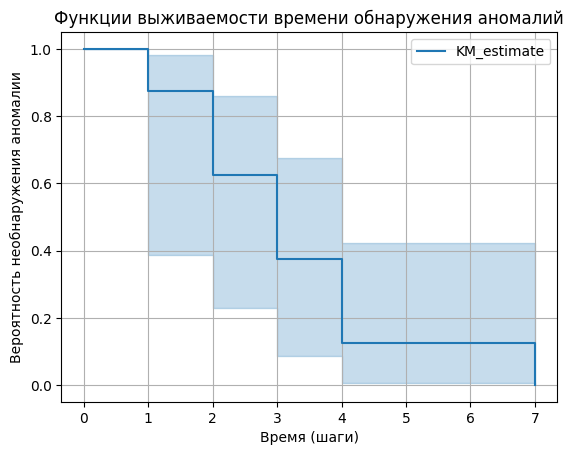

Аномалия 11:
  - Лучший PR AUC: 0.1636 (LocalOutlierFactor)
  - Лучший ROC AUC: 0.6772 (LocalOutlierFactor)

-------------------
Время выполнения: 307.4174 секунд


Запуск экспериментов для аномалии 12
   Итого: X.shape=(100000, 53), y.shape=(100000,)
   Доля аномалий: 0.0900
X_train.shape=(69416, 53), y_train.shape=(69416,), X_test.shape=(30584, 53), y_test.shape=(30584,), y_train.mean()=np.float64(0.09507894433559987), y_test.mean()=np.float64(0.07847240387130526)


In [ ]:
# reduced, without windows
anomaly_numbers = list(range(1, 20))
# anomaly_numbers = [1]

summary, summary_detectors = run_experiments_by_anomaly(anomaly_numbers,
                                     data_dir_template="./gen_data_reduced/gen_data_{}",
                                     model_params_list=model_params_list,
                                     max_samples=100000,
                                     file_fraction=0.05,
                                     anomaly_ratio=0.08,
                                     window=None,
                                     result_title="new_reduced_data_unsupervised_no_windows",
                                     results_path="results/cleared",
                                     autoencoder=None
                                     )

In [ ]:
summary_detectors

In [ ]:
# not reduced, without windows
anomaly_numbers = list(range(1, 20))
# anomaly_numbers = [1]

summary, summary_detectors = run_experiments_by_anomaly(anomaly_numbers,
                                     data_dir_template="./gen_data_new/gen_data_{}",
                                     model_params_list=model_params_list,
                                     max_samples=100000,
                                     file_fraction=0.05,
                                     anomaly_ratio=0.08,
                                     window=None,
                                     result_title="new_data_unsupervised_no_windows",
                                     results_path="results/cleared",
                                     autoencoder=None
                                     )

In [ ]:
summary_detectors

In [ ]:
# not reduced, autoencoder
anomaly_numbers = list(range(1, 20))
# anomaly_numbers = [1]

summary, summary_detectors = run_experiments_by_anomaly(anomaly_numbers,
                                     data_dir_template="./gen_data_new/gen_data_{}",
                                     model_params_list=model_params_list,
                                     max_samples=100000,
                                     file_fraction=0.05,
                                     anomaly_ratio=0.08,
                                     window=None,
                                     result_title="new_data_unsupervisedwith_autoencoder",
                                     results_path="results/cleared",
                                     autoencoder=autoencoder
                                     )

In [ ]:
summary_detectors